# Bays (2014) Figure 3 — Cued vs Uncued + Optimal Weighting (GP Model)

Replicates Figure 3: informative cueing experiment.

**Fixes (v2):** Correct SNR regime (γ=119 Hz total), λ=√ω,
correct additive log-gain encoding (not exponent), unweighted decoder.


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import time
from scipy.special import logsumexp
from scipy.stats import gaussian_kde

from core.encoder.gaussian_process import (
    generate_neuron_population, periodic_rbf_kernel, sample_gp_function,
)
from core.encoder.divisive_normalization import dn_pointwise
from core.encoder.poisson_spike import generate_spikes

print(f'Project root: {PROJECT_ROOT}')


Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


In [2]:
# Circular statistics + decoders
from scipy.special import i0, i1
from scipy.optimize import brentq
from scipy.stats import vonmises

def compute_log_likelihood(counts, g, T_d):
    log_g = np.log(np.maximum(g, 1e-30))
    return counts @ log_g - T_d * np.sum(g, axis=0)

def compute_circular_error(theta_true, theta_hat):
    return np.angle(np.exp(1j * (theta_hat - theta_true)))

def circular_variance(errors):
    """Circular variance V = 1 - rho1."""
    return 1.0 - np.abs(np.mean(np.exp(1j * errors)))

def circular_kurtosis(errors):
    """
    Fisher (1995) circular kurtosis, as used in Bays (2014):
        kappa = [rho2 * cos(Arg(m2) - 2*Arg(m1)) - rho1^4] / (1 - rho1)^2
    """
    m1 = np.mean(np.exp(1j * errors))
    m2 = np.mean(np.exp(2j * errors))
    rho1 = np.abs(m1)
    rho2 = np.abs(m2)
    V = 1.0 - rho1
    if V < 1e-10:
        return 0.0
    phase_correction = np.cos(np.angle(m2) - 2 * np.angle(m1))
    return (rho2 * phase_correction - rho1**4) / max(V**2, 1e-15)

def _estimate_von_mises_kappa(rho1):
    """Estimate von Mises concentration from mean resultant length."""
    if rho1 < 1e-6: return 0.0
    if rho1 > 0.9999: return 700.0
    return brentq(lambda k: float(i1(k)/i0(k)) - rho1, 1e-4, 700.0)

def compute_deviation_from_normal(errors, n_bins=50):
    """Compute empirical histogram and deviation from best-fit von Mises."""
    bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    emp, _ = np.histogram(errors, bins=bin_edges, density=True)
    rho1 = np.abs(np.mean(np.exp(1j * errors)))
    kappa_fit = _estimate_von_mises_kappa(rho1)
    vm_pdf = vonmises.pdf(centers, kappa_fit)
    return {'bin_centers': centers, 'empirical': emp,
            'normal_fit': vm_pdf, 'deviation': emp - vm_pdf}

# Multi-item factorised decoder (Eqs. 23-26)
def compute_spike_weighted_log_tuning(counts, f_list):
    return [counts @ f_k for f_k in f_list]

def compute_marginal_log_likelihood_efficient(L_list, cued_idx):
    ll = L_list[cued_idx].copy()
    for k in range(len(L_list)):
        if k != cued_idx:
            ll = ll + logsumexp(L_list[k])
    return ll

In [3]:
def generate_population(M, n_theta, lengthscale, n_locations=1, seed=42):
    population = generate_neuron_population(
        n_neurons=M, n_orientations=n_theta, n_locations=n_locations,
        base_lengthscale=lengthscale, lengthscale_variability=0.0, seed=seed)
    thetas = population[0]['orientations']
    f_all = []
    for loc in range(n_locations):
        f_loc = np.array([population[n]['f_samples'][loc, :] for n in range(M)])
        f_all.append(f_loc)
    return thetas, f_all

In [4]:
# ============================================================
# CONFIGURATION
# ============================================================
# SNR regime: Bays gamma=119 Hz is TOTAL subpop output.
# gamma_per_neuron = 119/M. lambda = sqrt(omega), omega~0.52.

M = 100; N_THETA = 128; N_TRIALS = 5000; N_TRIALS_SWEEP = 1000
T_D = 0.1; SIGMA_SQ = 1e-6

OMEGA_BAYS = 0.52
GAMMA_BAYS = 119.0
LAMBDA_BASE = np.sqrt(OMEGA_BAYS)    # 0.72
GAMMA = GAMMA_BAYS / M               # 1.19 Hz per neuron

SET_SIZES = [1, 2, 4, 8]; CUE_RATIO = 3.0
ALPHA_RANGE = (1.0, 5.0); N_ALPHA = 15
SEED = 42; N_SEEDS = 3; N_BINS = 50

print(f'Config: M={M}, n_theta={N_THETA}, gamma={GAMMA:.3f} Hz/neuron')
print(f'lambda={LAMBDA_BASE:.4f}, gamma_total={GAMMA*M:.1f} Hz')
print(f'Expected spikes/item at l=2: {GAMMA*M*T_D/2:.1f}')


Config: M=100, n_theta=128, gamma=1.190 Hz/neuron
lambda=0.7211, gamma_total=119.0 Hz
Expected spikes/item at l=2: 6.0


## Weighted encoder/decoder

**Bays (2014) Eq. 2–3**: The cue multiplies the *driving input* before normalization:

$$r_{ij}(\theta_j) = \gamma \cdot \frac{\alpha_j \cdot f_{ij}(\theta_j)}{\sum_{m,n} \alpha_n \cdot f_{mn}(\theta_n)}$$

In our GP model, $f_{n,k}(\theta_k)$ lives in log-space, so the multiplicative gain $\alpha_k$ becomes
an **additive constant** $\log \alpha_k$ in the log-drive:

$$\log r_n^{\text{pre}} = \sum_{k \in S} \bigl[ f_{n,k}(\theta_k) + \log \alpha_k \bigr]$$

This is **not** the same as $\alpha_k \cdot f_{n,k}$, which would raise the tuning curve
to the power $\alpha_k$.

The decoder reads out the **unweighted** log-tuning curves (the spike-weighted
$L_k(\theta_k) = \mathbf{n}^T F_k$), because the decoder uses the actual tuning curves
that generated the spikes, not the alpha-weighted versions. The alpha only affects
how much activity is *allocated* to each item during encoding.


In [5]:
def run_weighted_trials(f_all, thetas, active_locs, cued_loc, probed_loc,
                         alpha_cued, gamma, T_d, sigma_sq, n_trials, rng):
    """
    Encode with cue-weighted gain, decode with unweighted tuning curves.

    Encoding (Bays Eq. 2):
      alpha_k multiplies the driving input f_k, so in log-space:
      log r_pre = sum_k [ f_{n,k}(theta_k) + log(alpha_k) ]

    Decoding (Bays Eq. 6-8):
      The decoder uses the UNWEIGHTED tuning curves f_{n,k} to compute
      L_k(theta) = n^T F_k, then marginalises over uncued locations.
      Alpha does not appear in the decoder — it only affects encoding.
    """
    l = len(active_locs); M, n_theta = f_all[0].shape
    f_active = [f_all[loc] for loc in active_locs]

    # Build log-gain vector: log(alpha) for cued, 0 for uncued
    log_alpha = np.zeros(l)
    log_alpha[cued_loc] = np.log(alpha_cued)

    errors = np.empty(n_trials)
    for t in range(n_trials):
        theta_idx = rng.randint(n_theta, size=l)

        # --- ENCODING: additive log-gain (Bays Eq. 2) ---
        log_r_pre = np.zeros(M)
        for k in range(l):
            log_r_pre += f_active[k][:, theta_idx[k]] + log_alpha[k]
        r_pre = np.exp(log_r_pre - np.max(log_r_pre))  # numerical stability
        rates = dn_pointwise(r_pre, gamma, sigma_sq)
        counts = generate_spikes(rates, T_d, rng)

        # --- DECODING: unweighted tuning curves (Bays Eq. 6-8) ---
        L_list = compute_spike_weighted_log_tuning(counts, f_active)
        ll_m = compute_marginal_log_likelihood_efficient(L_list, probed_loc)
        errors[t] = compute_circular_error(
            thetas[theta_idx[probed_loc]], thetas[np.argmax(ll_m)])
    return errors


## Find optimal alpha + run full trials

In [6]:
t0 = time.time()
alpha_values = np.linspace(ALPHA_RANGE[0], ALPHA_RANGE[1], N_ALPHA)
max_locs = max(SET_SIZES)
thetas, f_all = generate_population(M, N_THETA, LAMBDA_BASE, max_locs, SEED)

# Phase 1: find optimal alpha per set size
# Optimal alpha minimises expected total error:
#   cost = p_cued * Var(cued) + (1-p_cued) * Var(uncued)
optimal_alphas = {}
for N in SET_SIZES:
    p_c = CUE_RATIO / (CUE_RATIO + N - 1)
    best_cost, best_alpha = np.inf, 1.0
    for alpha in alpha_values:
        rng_c = np.random.RandomState(SEED + N + int(alpha*100))
        ec = run_weighted_trials(f_all, thetas, tuple(range(N)), 0, 0,
                                  alpha, GAMMA, T_D, SIGMA_SQ, N_TRIALS_SWEEP, rng_c)
        rng_u = np.random.RandomState(SEED + N + int(alpha*100) + 50000)
        eu = run_weighted_trials(f_all, thetas, tuple(range(N)), 0, min(1,N-1),
                                  alpha, GAMMA, T_D, SIGMA_SQ, N_TRIALS_SWEEP, rng_u)
        cost = p_c * circular_variance(ec) + (1-p_c) * circular_variance(eu)
        if cost < best_cost:
            best_cost, best_alpha = cost, alpha
    optimal_alphas[N] = best_alpha
    print(f'  N={N}: alpha*={best_alpha:.2f} (p_cued={p_c:.2f})')

# Phase 2: full trials at optimal alpha
summary = {}
for N in SET_SIZES:
    alpha_opt = optimal_alphas[N]
    rng_c = np.random.RandomState(SEED + N*1000)
    ec = run_weighted_trials(f_all, thetas, tuple(range(N)), 0, 0,
                              alpha_opt, GAMMA, T_D, SIGMA_SQ, N_TRIALS, rng_c)
    rng_u = np.random.RandomState(SEED + N*1000 + 50000)
    eu = run_weighted_trials(f_all, thetas, tuple(range(N)), 0, min(1,N-1),
                              alpha_opt, GAMMA, T_D, SIGMA_SQ, N_TRIALS, rng_u)
    p_c = CUE_RATIO / (CUE_RATIO + N - 1)
    nc = int(round(p_c * N_TRIALS))
    ea = np.concatenate([ec[:nc], eu[:N_TRIALS-nc]])
    summary[N] = {
        'alpha': alpha_opt,
        'err_cued': ec, 'err_uncued': eu, 'err_all': ea,
        'vc': circular_variance(ec), 'vu': circular_variance(eu), 'va': circular_variance(ea),
        'kc': circular_kurtosis(ec), 'ku': circular_kurtosis(eu),
    }
    print(f'  N={N}: alpha={alpha_opt:.2f} vc={summary[N]["vc"]:.4f} vu={summary[N]["vu"]:.4f}')
print(f'Done in {time.time()-t0:.1f}s')


  N=1: alpha*=1.57 (p_cued=1.00)
  N=2: alpha*=1.00 (p_cued=0.75)
  N=4: alpha*=1.86 (p_cued=0.50)
  N=8: alpha*=4.14 (p_cued=0.30)
  N=1: alpha=1.57 vc=0.1068 vu=0.1078
  N=2: alpha=1.00 vc=0.1724 vu=0.1090
  N=4: alpha=1.86 vc=0.2629 vu=0.2476
  N=8: alpha=4.14 vc=0.4954 vu=0.4861
Done in 57.6s


## Plot: panels a-d

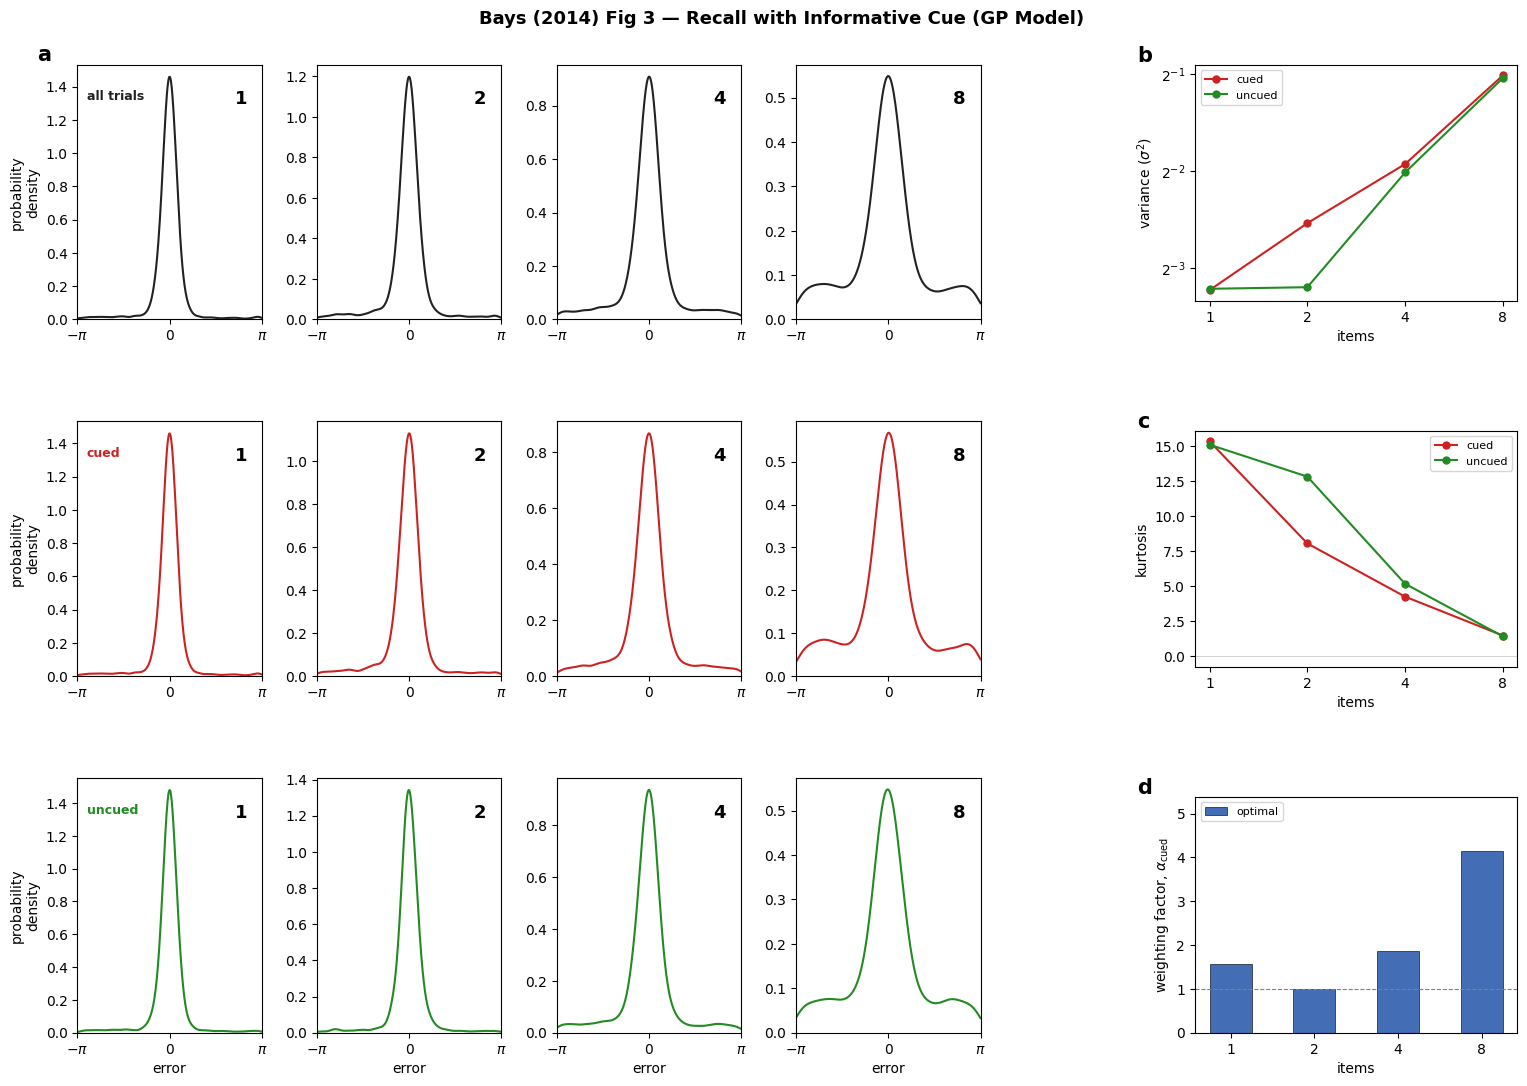

In [7]:
RED, GREEN, BLACK, BLUE = '#CC2222', '#228B22', '#222222', '#2255AA'
theta_smooth = np.linspace(-np.pi, np.pi, 500)

fig = plt.figure(figsize=(16, 11))
outer = gridspec.GridSpec(1, 2, width_ratios=[2.8, 1], wspace=0.35,
                          left=0.06, right=0.96, bottom=0.05, top=0.93)
gs_a = gridspec.GridSpecFromSubplotSpec(3, len(SET_SIZES),
    subplot_spec=outer[0], hspace=0.4, wspace=0.3)
gs_bcd = gridspec.GridSpecFromSubplotSpec(3, 1,
    subplot_spec=outer[1], hspace=0.55)
ns = np.array(SET_SIZES, dtype=float)

# === Panel a: error distributions (3 rows x 3 cols) ===
row_configs = [
    ('err_all', BLACK, 'all trials'),
    ('err_cued', RED, 'cued'),
    ('err_uncued', GREEN, 'uncued'),
]

for row, (err_key, color, label) in enumerate(row_configs):
    for col, N in enumerate(SET_SIZES):
        ax = fig.add_subplot(gs_a[row, col])
        err = summary[N][err_key]
        # KDE-smoothed error distribution (real simulation output)
        try:
            kde = gaussian_kde(err, bw_method=0.2)
            ax.plot(theta_smooth, kde(theta_smooth), color=color, lw=1.5)
        except Exception:
            ax.hist(err, bins=50, density=True, color=color, alpha=0.7)
        ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, None)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        if row == 2: ax.set_xlabel('error')
        ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
                fontsize=13, fontweight='bold', va='top', ha='right')
        if col == 0:
            ax.set_ylabel('probability\ndensity')
            ax.text(0.05, 0.90, label, transform=ax.transAxes,
                    fontsize=9, fontweight='bold', va='top', color=color)

fig.axes[0].text(-0.22, 1.08, r'$\mathbf{a}$', transform=fig.axes[0].transAxes,
                  fontsize=15, fontweight='bold', va='top')

# === Panel b: variance (cued vs uncued) ===
ax_b = fig.add_subplot(gs_bcd[0])
vc = [summary[N]['vc'] for N in SET_SIZES]
vu = [summary[N]['vu'] for N in SET_SIZES]
ax_b.plot(ns, vc, 'o-', color=RED, lw=1.5, ms=5, label='cued')
ax_b.plot(ns, vu, 'o-', color=GREEN, lw=1.5, ms=5, label='uncued')
ax_b.set_xscale('log', base=2); ax_b.set_yscale('log', base=2)
ax_b.set_xticks(SET_SIZES); ax_b.set_xticklabels([str(n) for n in SET_SIZES])
ax_b.set_xlabel('items'); ax_b.set_ylabel(r'variance ($\sigma^2$)')
ax_b.legend(fontsize=8, loc='upper left')
ax_b.text(-0.18, 1.08, r'$\mathbf{b}$', transform=ax_b.transAxes,
          fontsize=15, fontweight='bold', va='top')

# === Panel c: kurtosis (cued vs uncued) ===
ax_c = fig.add_subplot(gs_bcd[1])
kc = [summary[N]['kc'] for N in SET_SIZES]
ku = [summary[N]['ku'] for N in SET_SIZES]
ax_c.plot(ns, kc, 'o-', color=RED, lw=1.5, ms=5, label='cued')
ax_c.plot(ns, ku, 'o-', color=GREEN, lw=1.5, ms=5, label='uncued')
ax_c.set_xscale('log', base=2)
ax_c.set_xticks(SET_SIZES); ax_c.set_xticklabels([str(n) for n in SET_SIZES])
ax_c.set_xlabel('items'); ax_c.set_ylabel('kurtosis')
ax_c.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax_c.legend(fontsize=8, loc='upper right')
ax_c.text(-0.18, 1.08, r'$\mathbf{c}$', transform=ax_c.transAxes,
          fontsize=15, fontweight='bold', va='top')

# === Panel d: optimal weighting factor ===
ax_d = fig.add_subplot(gs_bcd[2])
bar_x = np.arange(len(SET_SIZES))
opt_alphas = [optimal_alphas[N] for N in SET_SIZES]
ax_d.bar(bar_x, opt_alphas, 0.5,
         color=BLUE, alpha=0.85, edgecolor='k', lw=0.5, label='optimal')
ax_d.axhline(1, color='gray', ls='--', lw=0.8)
ax_d.set_xticks(bar_x); ax_d.set_xticklabels([str(n) for n in SET_SIZES])
ax_d.set_xlabel('items')
ax_d.set_ylabel(r'weighting factor, $\alpha_{\mathrm{cued}}$')
ax_d.set_ylim(0, max(opt_alphas) * 1.3 if max(opt_alphas) > 1 else 2.0)
ax_d.legend(fontsize=8, loc='upper left')
ax_d.text(-0.18, 1.08, r'$\mathbf{d}$', transform=ax_d.transAxes,
          fontsize=15, fontweight='bold', va='top')

fig.suptitle('Bays (2014) Fig 3 \u2014 Recall with Informative Cue (GP Model)',
             fontsize=13, fontweight='bold')
plt.savefig('bays_fig3.png', dpi=150, bbox_inches='tight')
plt.show()
